[<img src="../../header.svg">](../index.ipynb)

---
# Tutorial 3: Adaptive Finite Elements
The nook problem from the [previous section](./tutorial-fem-02.ipynb) is an example, where the error was only concentrated in a small regions. In this section, it is illustrated, how adaptive refinement can contribute to overcome this problem.


Loading Domain 'grids/sector_ref0.ugx'...
Domain loaded.
Refining ...
Refining step {0} ...
Refining step {1} ...
Refining done


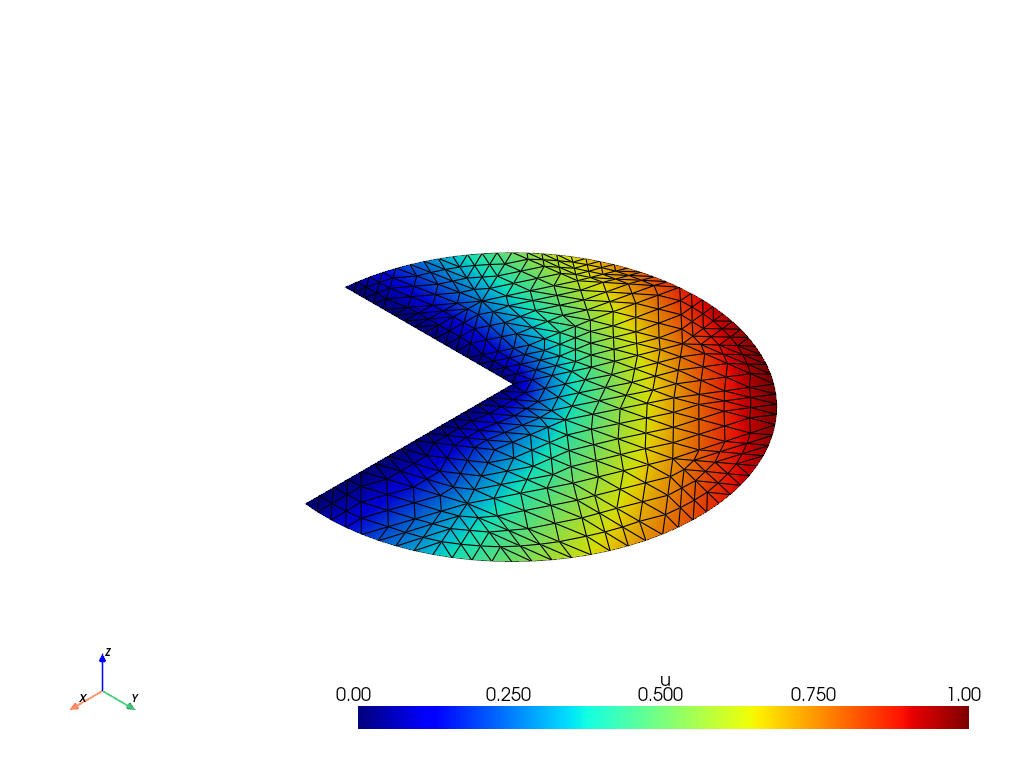

0.003029457752126185
0.023142464491492567


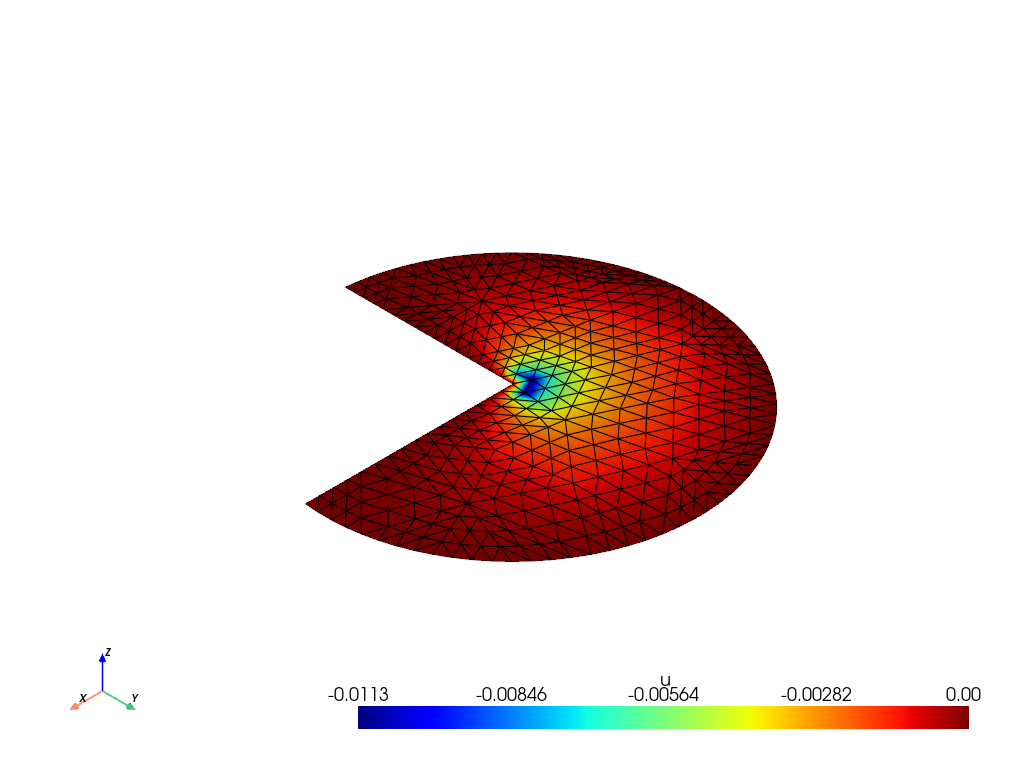

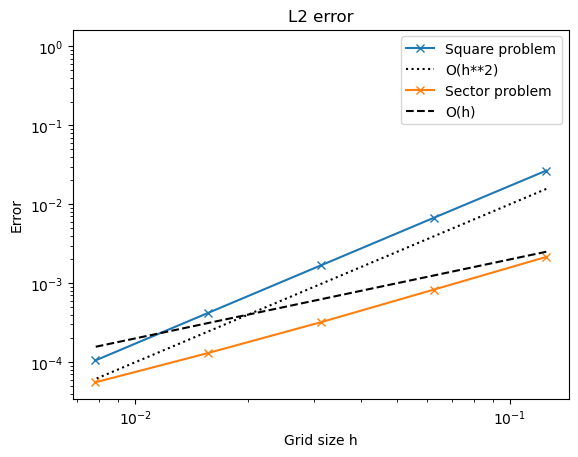

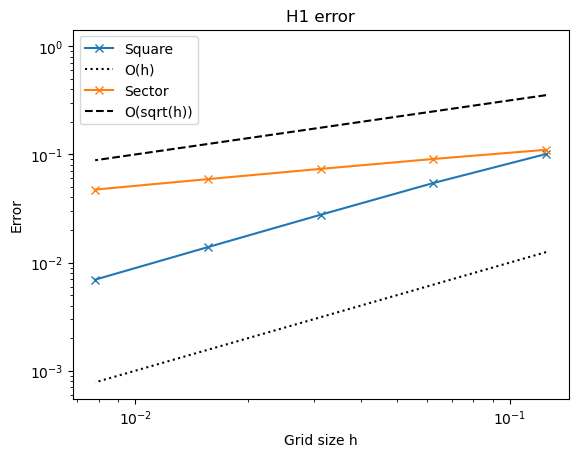

In [11]:
%run tutorial-fem-02.ipynb

In [12]:
maxLvl = 10
refTol = 1e-8

arefiner = ugcore.HangingNodeDomainRefiner(dom)
domainDisc.add(ugcore.SymP1Constraints2dCPU1())

In [13]:
approxSpace.print_statistic()
ugcore.MarkForAdaption_GradientIndicator(arefiner, uh, "u", 1e-8, 0.8, -1, maxLvl)

In [14]:
# center = ugcore.Vec2d()
# ugcore.MarkForRefinement_FacesInSphere(dom, arefiner, center, 0.25)

In [15]:
arefiner.refine() 
arefiner.clear_marks()
approxSpace.print_statistic()

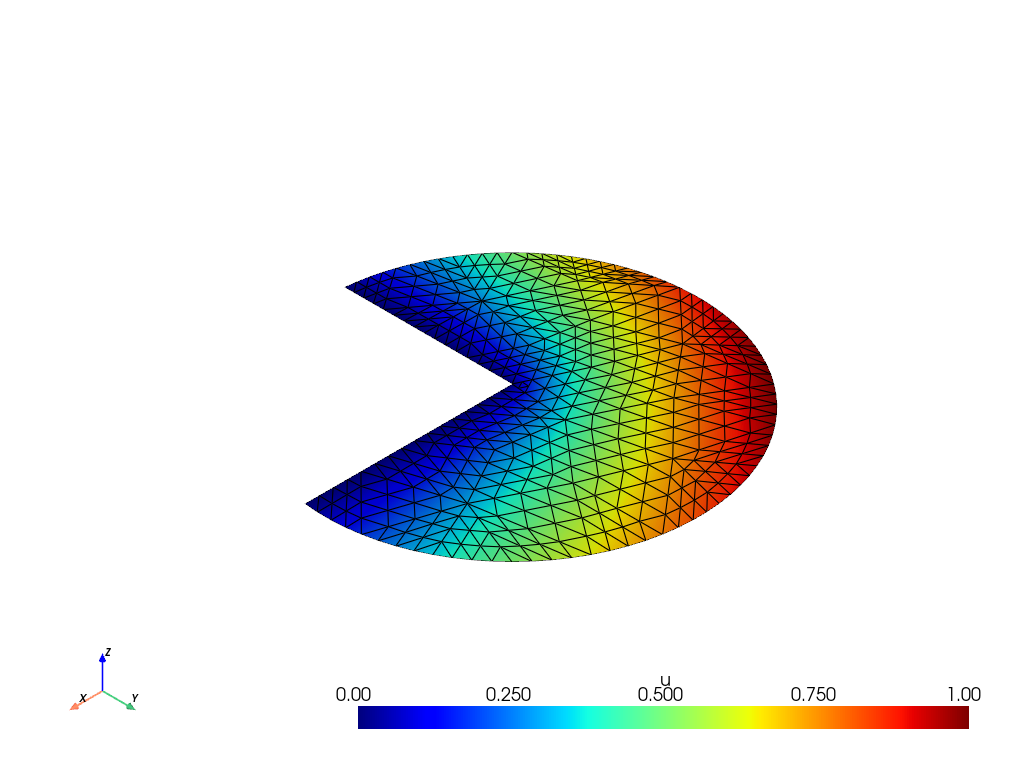

In [16]:
# solver=ugcore.LUCPU1()
try:
    domainDisc.assemble_linear(Ah, bh)
    domainDisc.adjust_solution(uh)
    solver.init(Ah, uh)
    solver.apply(uh, bh)
except Exception as inst:
    traceback.print_exc()
    print(inst)

ugcore.WriteGridFunctionToVTK(uh, "tmp/fem03_solution_u")
result = pyvista.read("tmp/fem03_solution_u.vtu")
result.plot(scalars="u", show_edges=True, cmap='jet')



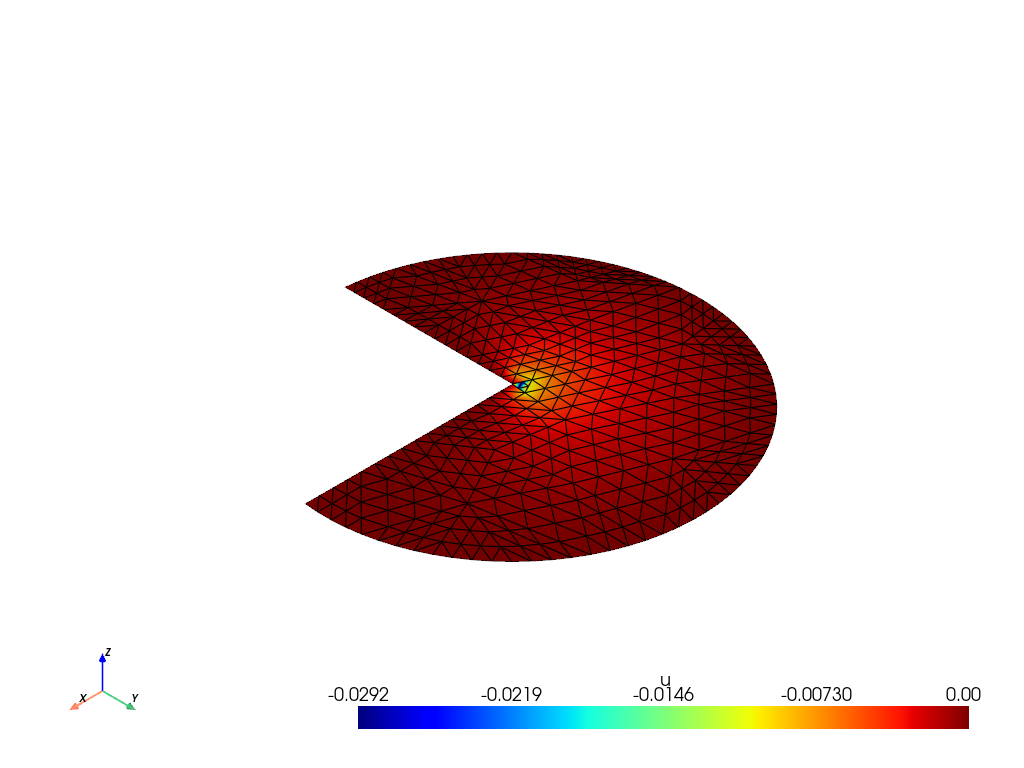

In [17]:

ugcore.Interpolate(ugcore.PythonUserNumber2d(CONFIG.SolutionCallback), uref, "u")
ugcore.VecScaleAdd2(errh, 1.0, uh, -1.0, uref)
ugcore.WriteGridFunctionToVTK(errh, "tmp/fem03_error")
result = pyvista.read("tmp/fem03_error.vtu")
result.plot(scalars="u", show_edges=True, cmap='jet')

In [10]:
def coarsening(uh, refiner):
    domainDisc.calc_error(uh)
    refiner.clear_marks()
    domainDisc.mark_with_strategy(uh)
    refiner.coarsen()
refinementMarking = ugcore.VarianceMarkingEta2d(0.25, 3, 0.05),
coarseningMarking = ugcore.APosterioriCoarsening2d(0.025), 